In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.optimize import minimize
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.linalg import eigh
from sklearn.covariance import GraphicalLassoCV
import scipy.cluster.hierarchy as sch
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
excel_file = 'crypto_data_real.xlsx'
df_returns = pd.read_excel(excel_file, sheet_name='Returns', index_col=0)
df_prices  = pd.read_excel(excel_file, sheet_name='Prices',  index_col=0)

crypto_names = df_returns.columns.tolist()
n_assets     = len(crypto_names)

print(f"Data loaded: {df_returns.shape[0]} days, {n_assets} assets")
print(f"Period: {df_returns.index[0]} to {df_returns.index[-1]}")

Data loaded: 763 days, 10 assets
Period: 2017-09-15 00:00:00 to 2019-10-17 00:00:00


In [3]:
summary_stats = pd.DataFrame({
    'Mean':     df_returns.mean(),
    'Std':      df_returns.std(),
    'Kurtosis': df_returns.kurt(),
    'Skewness': df_returns.skew()
})

print("TABLE 1 | Summary statistics.")
print(summary_stats.round(4))

TABLE 1 | Summary statistics.
        Mean     Std  Kurtosis  Skewness
BTC   0.0012  0.0434    3.0822    0.0523
ETH  -0.0008  0.0507    2.8209   -0.2916
XRP   0.0004  0.0654   18.9009    2.0588
USDT -0.0000  0.0057   21.7209    0.7437
BCH  -0.0014  0.0724    7.5671    0.6231
LTC   0.0004  0.0585    6.6357    1.0988
BNB   0.0029  0.0621   10.2612    1.0694
EOS   0.0012  0.0709    4.7582    0.5781
XLM   0.0006  0.0657    7.0332    0.9799
TRX   0.0025  0.0879   22.1856    2.6905


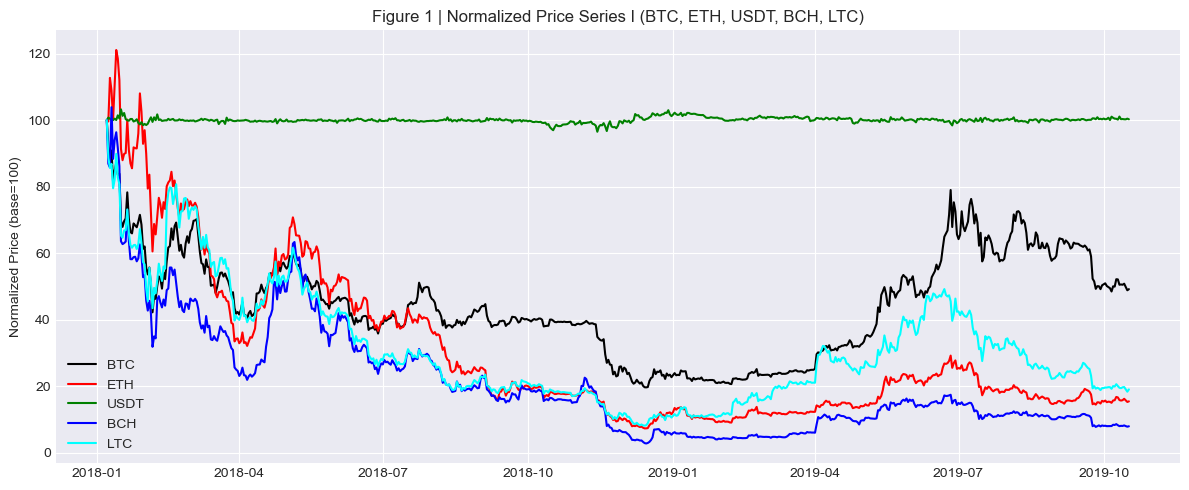

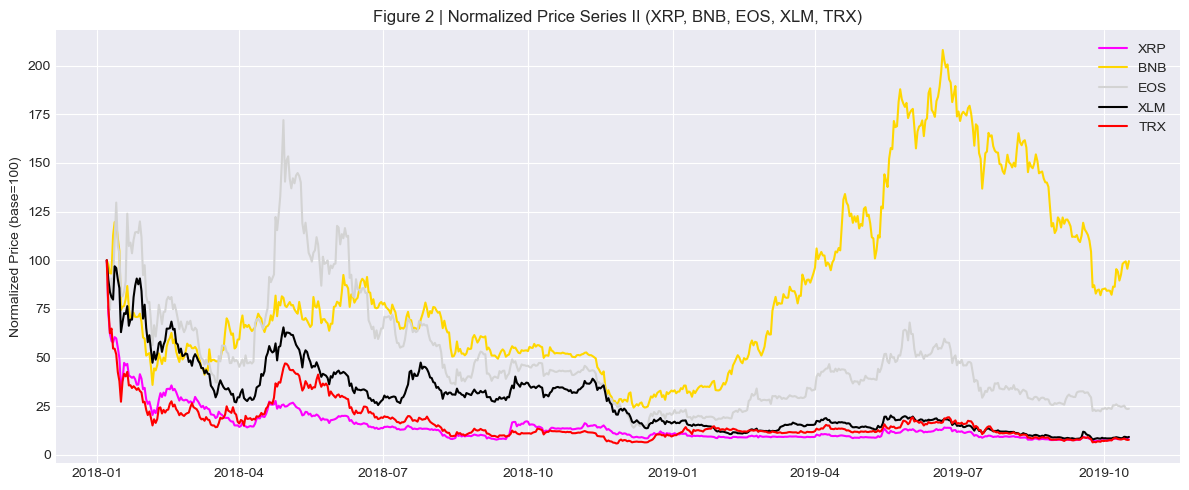

In [4]:
assets_1 = ['BTC', 'ETH', 'USDT', 'BCH', 'LTC']
df_norm_1 = (df_prices.loc['2018-01-07':, assets_1] /
             df_prices.loc['2018-01-07', assets_1]) * 100

colors_1 = ['black', 'red', 'green', 'blue', 'cyan']

plt.figure(figsize=(12, 5))
for i, col in enumerate(df_norm_1.columns):
    plt.plot(df_norm_1.index, df_norm_1[col],
             label=col, color=colors_1[i])
plt.title('Figure 1 | Normalized Price Series I (BTC, ETH, USDT, BCH, LTC)')
plt.ylabel('Normalized Price (base=100)')
plt.legend()
plt.tight_layout()
plt.show()

assets_2 = ['XRP', 'BNB', 'EOS', 'XLM', 'TRX']
df_norm_2 = (df_prices.loc['2018-01-07':, assets_2] /
             df_prices.loc['2018-01-07', assets_2]) * 100

colors_2 = ['magenta', 'gold', 'lightgrey', 'black', 'red']

plt.figure(figsize=(12, 5))
for i, col in enumerate(df_norm_2.columns):
    plt.plot(df_norm_2.index, df_norm_2[col],
             label=col, color=colors_2[i])
plt.title('Figure 2 | Normalized Price Series II (XRP, BNB, EOS, XLM, TRX)')
plt.ylabel('Normalized Price (base=100)')
plt.legend()
plt.tight_layout()
plt.show()

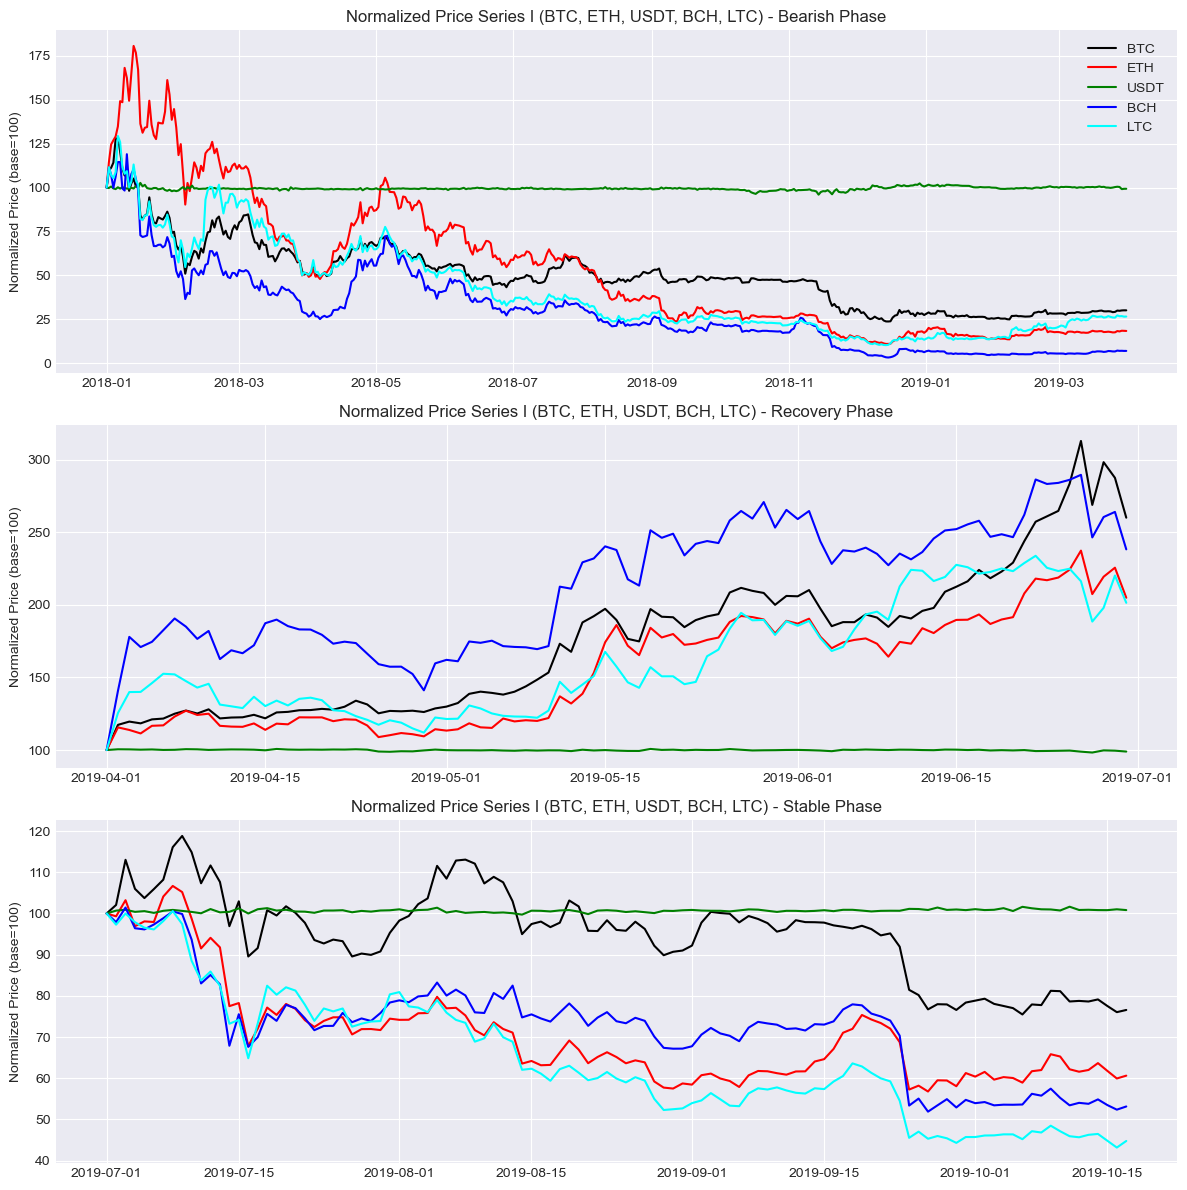

In [5]:
fase_pasar = {
    'Bearish':  ('2018-01-01', '2019-03-31'),
    'Recovery': ('2019-04-01', '2019-06-30'),
    'Stable':   ('2019-07-01', '2019-10-17')
}

assets_1 = ['BTC', 'ETH', 'USDT', 'BCH', 'LTC']
colors_1 = ['black', 'red', 'green', 'blue', 'cyan']

fig, axes = plt.subplots(3, 1, figsize=(12, 12))

for idx, (fase_name, (start_date, end_date)) in enumerate(fase_pasar.items()):
    ax = axes[idx]
    
    # Slice the price data for the current phase
    # Finding the actual start date available in the index that is >= start_date
    mask = (df_prices.index >= start_date) & (df_prices.index <= end_date)
    df_phase = df_prices.loc[mask, assets_1]
    
    if len(df_phase) > 0:
        # Normalize to base=100 at the beginning of the phase
        df_norm_phase = (df_phase / df_phase.iloc[0]) * 100
        
        for i, col in enumerate(df_norm_phase.columns):
            ax.plot(df_norm_phase.index, df_norm_phase[col], label=col, color=colors_1[i])
            
    ax.set_title(f'Normalized Price Series I (BTC, ETH, USDT, BCH, LTC) - {fase_name} Phase')
    ax.set_ylabel('Normalized Price (base=100)')
    if idx == 0:
        ax.legend()

plt.tight_layout()
plt.show()

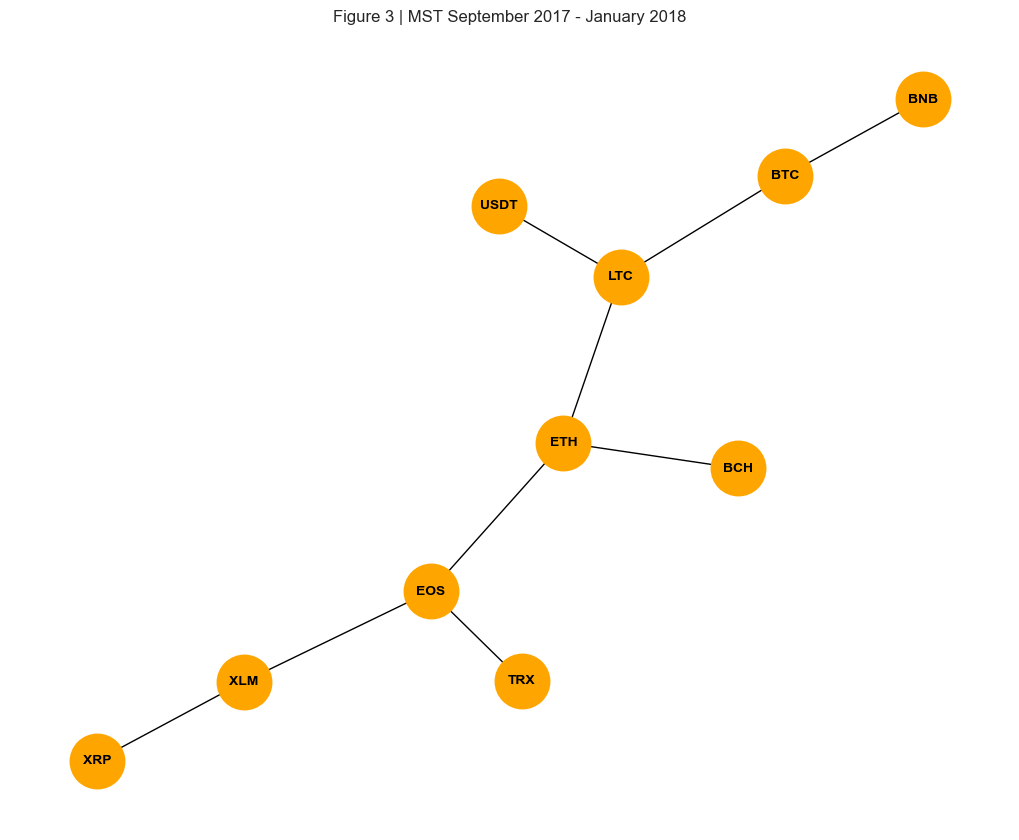

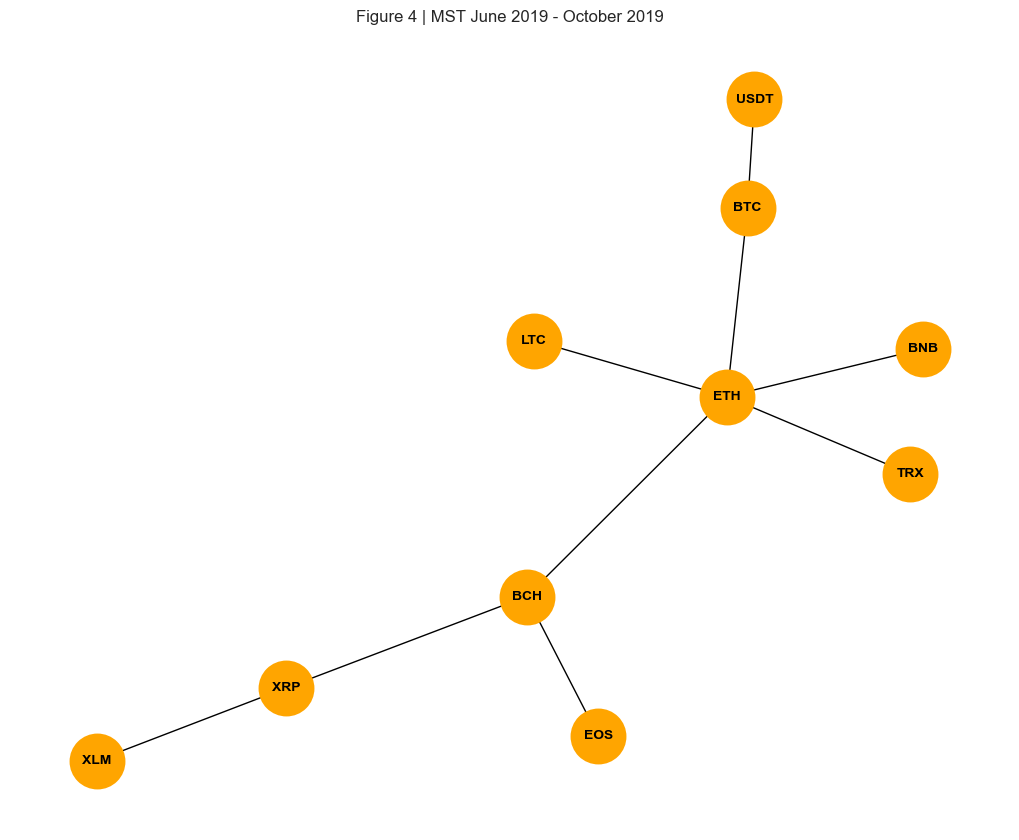

In [6]:
df_bubble   = df_returns.loc['2017-09-14':'2018-01-31']
corr_bubble = df_bubble.corr()
dist_bubble = np.sqrt(2 * (1 - corr_bubble))

G          = nx.from_pandas_adjacency(dist_bubble)
mst_bubble = nx.minimum_spanning_tree(G, weight='weight')

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(mst_bubble, seed=42)
nx.draw(mst_bubble, pos, with_labels=True, node_color='orange',
        node_size=1500, edge_color='black', linewidths=1.5,
        font_size=10, font_weight='bold')
plt.title('Figure 3 | MST September 2017 - January 2018', fontsize=12)
plt.show()

df_stable   = df_returns.loc['2019-06-01':'2019-10-17']
corr_stable = df_stable.corr()
dist_stable = np.sqrt(2 * (1 - corr_stable))

G2         = nx.from_pandas_adjacency(dist_stable)
mst_stable = nx.minimum_spanning_tree(G2, weight='weight')

plt.figure(figsize=(10, 8))
pos2 = nx.spring_layout(mst_stable, seed=42)
nx.draw(mst_stable, pos2, with_labels=True, node_color='orange',
        node_size=1500, edge_color='black', linewidths=1.5,
        font_size=10, font_weight='bold')
plt.title('Figure 4 | MST June 2019 - October 2019', fontsize=12)
plt.show()

In [7]:
def apply_rmt_filter(returns_data):
    """
    Menerapkan filter Random Matrix Theory (RMT) pada matriks korelasi aset.
    
    Fungsi ini bertujuan untuk memisahkan "sinyal" (informasi pasar yang sebenarnya) 
    dari "noise" (fluktuasi acak) dalam matriks korelasi imbal hasil (returns) aset. 
    Metode ini sangat berguna dalam optimasi portofolio untuk mencegah terjadinya over-fitting 
    terhadap noise historis, sehingga estimasi matriks korelasi yang dihasilkan menjadi 
    lebih stabil dan dapat diandalkan (robust).

    Alur Narasi Proses:
    1. Persiapan Data: Memastikan data berformat matriks numpy agar siap diolah.
    2. Korelasi Empiris: Membentuk matriks korelasi Pearson standar dari data imbal hasil.
    3. Dekomposisi Eigen: Memecah matriks korelasi menjadi nilai eigen dan vektor eigen untuk 
       melihat varians dari komponen utama.
    4. Thresholding Marchenko-Pastur: Menghitung ambang batas (lambda_plus) acak 
       berdasarkan teori matriks acak.
    5. Penyaringan (Filtering): Memilah mana nilai eigen yang "nyata" (sinyal) 
       dan mana yang "acak" (noise). Noise kemudian dihilangkan (di-nol-kan).
    6. Rekonstruksi: Membangun kembali matriks korelasi baru yang sudah dibersihkan dari noise.

    Parameters:
    -----------
    returns_data : pandas.DataFrame atau numpy.ndarray
        Data deret waktu imbal hasil (returns) dari berbagai aset. 
        Asumsi format: Baris (T observasi) x Kolom (N aset).

    Returns:
    --------
    C_filtered : numpy.ndarray
        Matriks korelasi baru (N x N) yang telah disaring dan dibersihkan dari noise.
    """
    
    if isinstance(returns_data, pd.DataFrame):
        data = returns_data.values
    else:
        data = returns_data
        
    T, N = data.shape
    
    Q = T / N
    
    C = np.corrcoef(data.T)

    eigenvalues, eigenvectors = eigh(C)
    
    eigenvalues  = eigenvalues[::-1]
    eigenvectors = eigenvectors[:, ::-1]

    lambda_plus = 1 + (1/Q) + 2*np.sqrt(1/Q)
    
    significant_mask = eigenvalues > lambda_plus

    Lambda_filtered = np.diag(np.where(significant_mask, eigenvalues, 0))
    
    C_filtered = eigenvectors @ Lambda_filtered @ eigenvectors.T
    
    return C_filtered

def build_mst(correlation_matrix):
    """
    Menghitung matriks jarak (Distance Matrix) dari matriks korelasi sebagai
    tahap pra-pemrosesan untuk pembentukan Minimum Spanning Tree (MST).
    
    Transformasi ini menggunakan metrik jarak Mantegna (1999) yang secara
    umum didefinisikan sebagai d_ij = sqrt(2 * (1 - rho_ij)). Metrik ini
    mentransformasikan korelasi (Pearson) ke dalam ruang Euclidean.
    
    Matematika Transformasi:
    1. Jika rho =  1 (Korelasi Positif Sempurna), maka d = 0 (Jarak terdekat).
    2. Jika rho =  0 (Tidak Ada Korelasi),       maka d = sqrt(2) ≈ 1.41.
    3. Jika rho = -1 (Korelasi Negatif Sempurna), maka d = 2 (Jarak terjauh).
    
    Parameters:
    -----------
    correlation_matrix : numpy.ndarray
        Matriks korelasi antar aset berukuran (N x N). Matriks ini harus
        bersifat simetris dan memiliki nilai diagonal bernilai 1.0.
        
    Returns:
    --------
    distance_matrix : numpy.ndarray
        Matriks jarak berukuran (N x N) yang memenuhi sifat-sifat metrik:
        - Non-negatif: d_ij >= 0
        - Identitas: d_ii = 0
        - Simetris: d_ij = d_ji
        - Ketidaksamaan Segitiga: d_ij <= d_ik + d_kj
    """
    
    distance_matrix = np.sqrt(2 - 2 * correlation_matrix)
    
    np.fill_diagonal(distance_matrix, 0)
    
    return distance_matrix

def compute_eigenvector_centrality(distance_matrix):
    """
    Menghitung skor Eigenvector Centrality dari matriks jarak (Distance Matrix).
    
    Eigenvector centrality memberikan ukuran seberapa 'penting' suatu aset 
    di dalam jaringan. Berbeda dengan degree centrality (yang hanya menghitung 
    jumlah koneksi), eigenvector centrality mempertimbangkan kualitas koneksi; 
    suatu aset dianggap penting jika ia terhubung dengan aset-aset lain yang 
    juga memiliki kepentingan tinggi.
    
    Dalam studi portofolio (Network Markowitz), metrik ini digunakan untuk 
    mendeteksi aset sistemik atau aset yang berada di pusat kluster risiko.
    Parameters:
    -----------
    distance_matrix : numpy.ndarray
        Matriks jarak berukuran (N x N). Nilai kecil pada matriks ini 
        menunjukkan korelasi yang kuat antar aset.
    Returns:
    --------
    centrality : numpy.ndarray
        Vektor berukuran (N,) berisi skor centrality yang dinormalisasi.
        Nilai yang lebih tinggi menunjukkan aset yang lebih sentral di pasar.
    """
    
    adjacency = 1 / (distance_matrix + 1e-8)
    
    np.fill_diagonal(adjacency, 0)
    
    eigenvalues, eigenvectors = eigh(adjacency)
    
    principal_eigenvector = np.abs(eigenvectors[:, -1])
    
    centrality = principal_eigenvector / principal_eigenvector.sum()
    
    return centrality

def calculate_var(returns, confidence=0.95):
    """
    Menghitung Value at Risk (VaR) menggunakan metode Simulasi Historis.
    
    Value at Risk (VaR) adalah metrik risiko statistik yang mengestimasi 
    potensi kerugian maksimum dalam portofolio pada tingkat kepercayaan 
    tertentu dalam periode waktu tertentu.
    
    Contoh Interpretasi:
    Jika VaR(95%) bernilai -0.02, artinya kita memiliki keyakinan 95% bahwa 
    kerugian portofolio tidak akan melebihi 2% dalam satu hari kerja, 
    atau terdapat peluang 5% bahwa kerugian akan melampaul 2%.

    Parameters:
    -----------
    returns : numpy.ndarray | pandas.Series
        Data historis imbal hasil (return) dari aset atau portofolio.
    confidence : float, default 0.95
        Tingkat kepercayaan (confidence level). 0.95 berarti kita fokus 
        pada 5% kemungkinan terburuk (significance level alpha = 0.05).

    Returns:
    --------
    var_value : float
        Nilai batas bawah (threshold) imbal hasil pada persentil yang ditentukan.
    """
    
    alpha = 1 - confidence
    
    var_value = np.percentile(returns, alpha * 100)
    
    return var_value

def calculate_rachev_ratio(returns, alpha=0.10):
    """
    Menghitung Rachev Ratio untuk mengukur efisiensi imbal hasil pada ekor distribusi.
    
    Rachev Ratio mengukur perbandingan antara potensi keuntungan ekstrem (reward) 
    terhadap potensi kerugian ekstrem (risk). Berbeda dengan Sharpe Ratio, 
    metrik ini sangat efektif untuk aset dengan distribusi non-normal (fat-tails) 
    dan asimetris (skewed), yang umum ditemukan di pasar cryptocurrency.

    Formula:
    Rachev Ratio = CVaR(alpha, upper) / CVaR(alpha, lower)

    Interpretasi:
    Nilai > 1 menunjukkan bahwa potensi keuntungan di ekor kanan distribusi 
    lebih besar dibandingkan potensi kerugian di ekor kiri pada tingkat kepercayaan 1-alpha.

    Parameters:
    -----------
    returns : numpy.ndarray | pandas.Series
        Data historis imbal hasil (returns) strategi.
    alpha : float, default 0.10
        Tingkat signifikansi (probability tail). Misal 0.10 berarti kita 
        menganalisis 10% kejadian paling ekstrem (terbaik vs terburuk).

    Returns:
    --------
    rachev_ratio : float
        Rasio antara CVaR Atas per CVaR Bawah.
    """
    
    threshold_upper = np.percentile(returns, (1 - alpha) * 100)
    threshold_lower = np.percentile(returns, alpha * 100)
    
    cvar_upper = returns[returns >= threshold_upper].mean()
    
    cvar_lower = abs(returns[returns <= threshold_lower].mean())
    
    if cvar_lower > 0:
        rachev_ratio = cvar_upper / cvar_lower
    else:
        rachev_ratio = 0
        
    return rachev_ratio

def calculate_max_drawdown(cumulative_returns):
    """
    Menghitung Maximum Drawdown (MDD) dari deret imbal hasil kumulatif.
    
    Maximum Drawdown mengukur penurunan persentase terbesar yang diamati dari 
    titik puncak (peak) ke titik terendah (trough) dalam suatu periode waktu, 
    sebelum titik puncak baru terbentuk. Ini mencerminkan risiko kerugian 
    ekstrem yang mungkin dialami investor.

    Interpretasi:
    - Jika MDD = -0.25, berarti strategi tersebut pernah mengalami penurunan 
      nilai sebesar 25% dari titik tertingginya.
    - Semakin mendekati 0, semakin baik ketahanan strategi dalam menjaga modal.

    Parameters:
    -----------
    cumulative_returns : numpy.ndarray | pandas.Series
        Deret imbal hasil kumulatif (kurva ekuitas). 
        Pastikan input adalah data kumulatif (misal: 1, 1.05, 1.02, 1.08).

    Returns:
    --------
    max_drawdown : float
        Nilai penurunan maksimum dalam bentuk desimal (selalu <= 0).
    """

    running_max = np.maximum.accumulate(cumulative_returns)
    
    drawdown = (cumulative_returns - running_max) / running_max
    
    max_drawdown = drawdown.min()

    return max_drawdown

def get_assets_graph_diversify(returns_window, corr_threshold=0.4):
    """
    Melakukan seleksi aset untuk diversifikasi menggunakan algoritma 
    Maximum Independent Set (MIS) berbasis teori jaringan.
    
    Konsep Dasar Jaringan:
    1. Node (Simpul): Mewakili aset kripto dalam semesta portofolio.
    2. Edge (Sisi): Menghubungkan dua aset jika korelasi absolutnya melampaui 
       batas 'corr_threshold'. Sisi ini melambangkan 'redundansi' informasi risiko.
    3. Independent Set: Kumpulan aset yang TIDAK saling terhubung satu sama lain.
       Artinya, tidak ada aset dalam set ini yang memiliki korelasi tinggi.
    
    Tujuan Utama:
    Menemukan jumlah aset terbanyak yang memiliki tingkat ketergantungan (korelasi) 
    paling rendah satu sama lain demi memaksimalkan efek diversifikasi.
    Parameters:
    -----------
    returns_window : pandas.DataFrame
        Window data historis return aset (T bare x N kolom).
    corr_threshold : float, default 0.4
        Parameter theta (θ). Ambang batas di mana korelasi dianggap 'terlalu kuat'.
        Semakin rendah nilainya, semakin sedikit aset yang terpilih (diversifikasi sangat ketat).
    Returns:
    --------
    selected_assets : list
        Daftar nama aset terverifikasi yang membentuk Independent Set terbesar.
    """
    
    corr_mat = returns_window.corr()
    
    G = nx.Graph()
    
    assets = list(returns_window.mean()
                    .sort_values(ascending=False).index)
    
    G.add_nodes_from(assets)
    
    for i, a1 in enumerate(assets):
        for a2 in assets[i+1:]:
            if abs(corr_mat.loc[a1, a2]) > corr_threshold:
                G.add_edge(a1, a2)
    
    selected_assets = list(nx.approximation.maximum_independent_set(G))
    
    return selected_assets

def get_assets_graph_diversify_rmt(returns_window, corr_threshold=0.4):
    """
    Menyeleksi aset independen melalui jaringan graf yang telah difilter 
    menggunakan Random Matrix Theory (RMT).
    
    Keunggulan Metodologi RMT-Graph:
    1. Korelasi historis standar seringkali dipenuhi oleh 'noise' (gangguan) 
       akibat window data yang terbatas (fat-tails).
    2. RMT memisahkan eigenvalue korelasi menjadi dua bagian: 'noise' (yang 
       berada dalam bulk Marchenko-Pastur) dan 'signal' (eigenvalue yang keluar).
    3. Dengan menggunakan 'Filtered Correlation' (corr_f), sisi (edge) pada 
       graf hanya ditarik jika terdapat hubungan ekonomi yang benar-benar 
       signifikan (pure signal), bukan karena kebetulan statistik.
    Parameters:
    -----------
    returns_window : pandas.DataFrame
        Dataframe imbal hasil aset (N x T).
    corr_threshold : float, default 0.4
        Ambang batas (theta) untuk menentukan apakah signal korelasi 
        cukup kuat untuk membentuk koneksi antar aset.
    Returns:
    --------
    selected_assets_rmt : list
        Kumpulan aset independen (Maximum Independent Set) hasil filter RMT.
    """
    
    assets = returns_window.columns.tolist()
    
    corr_f = apply_rmt_filter(returns_window)
    
    G = nx.Graph()
    G.add_nodes_from(assets)
    
    for i, a1 in enumerate(assets):
        for j, a2 in enumerate(assets):
            if i < j:
                if abs(corr_f[i, j]) > corr_threshold:
                    G.add_edge(a1, a2)
    
    selected_assets_rmt = list(nx.approximation.maximum_independent_set(G))
    
    return selected_assets_rmt

print("Helper functions defined successfully!")

Helper functions defined successfully!


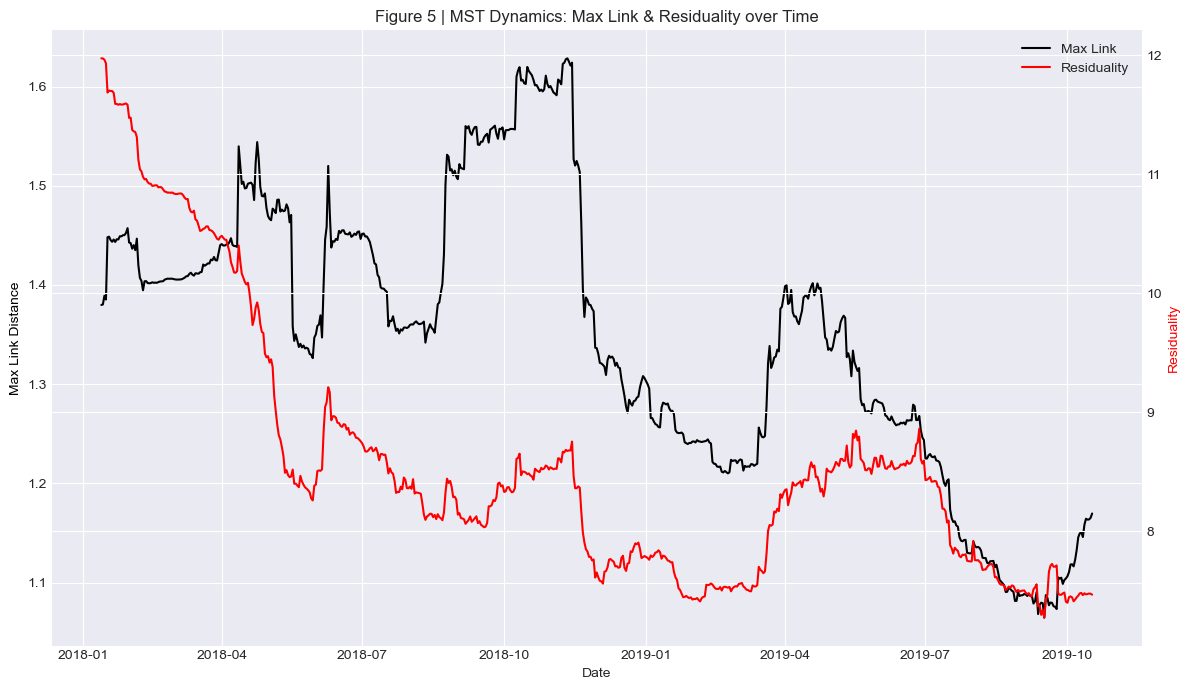

In [8]:
def calculate_rolling_mst_metrics(returns_df, window=120):
    """Hitung dinamika MST dengan rolling window."""
    dates          = returns_df.index[window:]
    max_links      = []
    residualities  = []
    for i in range(window, len(returns_df)):
        window_data = returns_df.iloc[i - window:i]
        corr_f      = apply_rmt_filter(window_data)
        mst_weights = build_mst(corr_f)
        max_links.append(np.max(mst_weights))
        residualities.append(
            np.sum(mst_weights) / (returns_df.shape[1] - 1)
        )
    return pd.DataFrame(
        {'Max Link': max_links, 'Residuality': residualities},
        index=dates
    )

mst_dyn = calculate_rolling_mst_metrics(df_returns)

fig, ax1 = plt.subplots(figsize=(12, 7))
ax1.plot(mst_dyn.index, mst_dyn['Max Link'],
         color='black', label='Max Link')
ax1.set_ylabel('Max Link Distance', color='black')
ax1.set_xlabel('Date')

ax2 = ax1.twinx()
ax2.plot(mst_dyn.index, mst_dyn['Residuality'],
         color='red', label='Residuality')
ax2.set_ylabel('Residuality', color='red')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('Figure 5 | MST Dynamics: Max Link & Residuality over Time')
plt.tight_layout()
plt.show()

In [9]:
class PortfolioStrategy:
    def __init__(self, name, window_size=120):
        self.name            = name
        self.window_size     = window_size
        self.weights_history = []
        self.returns_history = []
    def get_weights(self, returns_data):
        raise NotImplementedError

class EquallyWeighted(PortfolioStrategy):
    def get_weights(self, returns_data):
        n = returns_data.shape[1]
        return np.ones(n) / n

class ClassicalMarkowitz(PortfolioStrategy):
    """Optimasi Mean-Variance tradisional (minimasi varians portofolio)."""
    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        std = returns_data.std()
        valid_assets = std > 1e-12
        if not valid_assets.any(): return np.ones(n_assets) / n_assets
        filtered_data = returns_data.loc[:, valid_assets]
        mu = filtered_data.mean().values
        S  = filtered_data.cov().fillna(0).values
        S  += np.eye(len(mu)) * 1e-8
        objective   = lambda w: w @ S @ w
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(len(mu)) / len(mu),
                       method='SLSQP',
                       bounds=[(0, 1)] * len(mu),
                       constraints=constraints)
        weights = np.zeros(n_assets)
        weights[valid_assets] = res.x if res.success else (np.ones(len(mu)) / len(mu))
        return weights

class GlassoMarkowitz(PortfolioStrategy):
    """Markowitz dengan matriks presisi yang diestimasi via Graphical Lasso."""
    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        std = returns_data.std()
        valid_assets = std > 1e-12
        if not valid_assets.any(): return np.ones(n_assets) / n_assets
        filtered_data = returns_data.loc[:, valid_assets]
        mu = filtered_data.mean().values
        try:
            glasso = GraphicalLassoCV()
            glasso.fit(filtered_data.values)
            S = glasso.covariance_
        except Exception:
            S = filtered_data.cov().fillna(0).values
        S += np.eye(len(mu)) * 1e-8
        objective   = lambda w: w @ S @ w
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(len(mu)) / len(mu),
                       method='SLSQP',
                       bounds=[(0, 1)] * len(mu),
                       constraints=constraints)
        weights = np.zeros(n_assets)
        weights[valid_assets] = res.x if res.success else (np.ones(len(mu)) / len(mu))
        return weights

class NetworkMarkowitz(PortfolioStrategy):
    """Network Markowitz: RMT + MST + penalti sentralitas eigenvector."""
    def __init__(self, name="Network Markowitz", gamma=0, window_size=120):
        super().__init__(name, window_size)
        self.gamma = gamma

    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        std = returns_data.std()
        valid_assets = std > 1e-12
        if not valid_assets.any(): return np.ones(n_assets) / n_assets
        filtered_data = returns_data.loc[:, valid_assets]
        mu   = filtered_data.mean().values
        sig  = filtered_data.std().values
        Cf   = apply_rmt_filter(filtered_data)
        dist = build_mst(Cf)
        cent = compute_eigenvector_centrality(dist)
        Sf   = np.outer(sig, sig) * Cf
        Sf += np.eye(len(mu)) * 1e-8
        objective   = lambda w: w @ Sf @ w + self.gamma * np.sum(cent * w)
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(len(mu)) / len(mu),
                       method='SLSQP',
                       bounds=[(0, 1)] * len(mu),
                       constraints=constraints)
        weights = np.zeros(n_assets)
        weights[valid_assets] = res.x if res.success else (np.ones(len(mu)) / len(mu))
        return weights

class HybridMISNetworkMarkowitz(PortfolioStrategy):
    """
    Hybrid MIS-NW: 
    1. Seleksi aset via Maximum Independent Set (MIS) berbasis filter RMT.
    2. Optimasi alokasi via Network Markowitz pada subset aset terpilih.
    """
    def __init__(self, name="Hybrid MIS-NW", gamma=0.5, corr_threshold=0.4, window_size=120):
        super().__init__(name, window_size)
        self.gamma = gamma
        self.corr_threshold = corr_threshold

    def get_weights(self, returns_data):
        n_assets_total = returns_data.shape[1]
        all_asset_names = returns_data.columns
        
        # 1. Seleksi Aset via MIS (Random Matrix Theory Filtered)
        selected_assets = get_assets_graph_diversify_rmt(returns_data, self.corr_threshold)
        
        # Jika aset terpilih terlalu sedikit, gunakan semua aset yang valid (fallback)
        if len(selected_assets) < 2:
            filtered_data = returns_data
            is_subset = False
        else:
            filtered_data = returns_data[selected_assets]
            is_subset = True
            
        # 2. Network Markowitz Optimization pada subset
        n_sub = filtered_data.shape[1]
        mu   = filtered_data.mean().values
        sig  = filtered_data.std().values
        
        # Handle zero volatility
        valid_mask = sig > 1e-12
        if not valid_mask.any():
            final_weights = np.zeros(n_assets_total)
            return final_weights
            
        # NW logic on selected subset
        # Filter korelasi subset
        Cf_sub = apply_rmt_filter(filtered_data)
        dist_sub = build_mst(Cf_sub)
        cent_sub = compute_eigenvector_centrality(dist_sub)
        
        sig_v = sig
        Sf_sub = np.outer(sig_v, sig_v) * Cf_sub
        Sf_sub += np.eye(n_sub) * 1e-8
        
        objective = lambda w: w @ Sf_sub @ w + self.gamma * np.sum(cent_sub * w)
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        
        res = minimize(objective, np.ones(n_sub) / n_sub,
                       method='SLSQP',
                       bounds=[(0, 1)] * n_sub,
                       constraints=constraints)
        
        sub_weights = res.x if res.success else (np.ones(n_sub) / n_sub)
        
        # 3. Map back to total assets universe
        final_weights = np.zeros(n_assets_total)
        if is_subset:
            for idx, asset_name in enumerate(selected_assets):
                # Cari indeks asli
                orig_idx = all_asset_names.get_loc(asset_name)
                final_weights[orig_idx] = sub_weights[idx]
        else:
            final_weights = sub_weights
            
        return final_weights


class HRPPortfolioStrategy(PortfolioStrategy):
    """
    Hierarchical Risk Parity (HRP)
    Uses hierarchical clustering to group assets based on correlation, 
    then performs recursive bisection for weights allocation.
    """
    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        std = returns_data.std()
        valid_assets = std > 1e-12
        if not valid_assets.any(): return np.ones(n_assets) / n_assets
        
        filtered_data = returns_data.loc[:, valid_assets]
        assets_names = filtered_data.columns
        cov = filtered_data.cov().fillna(0).values
        corr = filtered_data.corr().fillna(0).values
        
        # 1. Clustering
        dist = np.sqrt(0.5 * (1 - np.clip(corr, -1, 1)))
        link = sch.linkage(sch.distance.squareform(dist), 'single')
        sort_ix = sch.leaves_list(link)
        
        # 2. Recursive Bisection
        weights = pd.Series(1.0, index=assets_names[sort_ix])
        
        def get_cluster_var(cov, cluster_items):
            sub_cov = cov[cluster_items, :][:, cluster_items]
            inv_diag = 1.0 / np.diag(sub_cov)
            w_inv = inv_diag / inv_diag.sum()
            return np.dot(w_inv, np.dot(sub_cov, w_inv))

        def recursive_bisection(cov, sort_ix):
            if len(sort_ix) <= 1:
                return
            mid = len(sort_ix) // 2
            left = sort_ix[:mid]
            right = sort_ix[mid:]
            var_l = get_cluster_var(cov, left)
            var_r = get_cluster_var(cov, right)
            alpha = 1 - var_l / (var_l + var_r)
            weights.iloc[left] *= alpha
            weights.iloc[right] *= (1 - alpha)
            recursive_bisection(cov, left)
            recursive_bisection(cov, right)

        recursive_bisection(cov, list(range(len(sort_ix))))
        full_weights = np.zeros(n_assets)
        full_weights[valid_assets] = weights.reindex(assets_names).values
        return full_weights

class KMeansPortfolioStrategy(PortfolioStrategy):
    """
    K-Means Clustering Portfolio
    Clusters assets into N groups, then performs Equal Weighting across 
    and within clusters to ensure structural diversification.
    """
    def __init__(self, name="K-Means ML", n_clusters=4, window_size=120):
        super().__init__(name, window_size)
        self.n_clusters = n_clusters

    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        std = returns_data.std()
        valid_assets = std > 1e-12
        if not valid_assets.any(): return np.ones(n_assets) / n_assets
        
        filtered_data = returns_data.loc[:, valid_assets]
        n_filtered = filtered_data.shape[1]
        actual_clusters = min(self.n_clusters, n_filtered)
        corr = filtered_data.corr().fillna(0).values
        
        kmeans = KMeans(n_clusters=actual_clusters, random_state=42, n_init='auto').fit(corr)
        labels = kmeans.labels_
        
        weights_sub = np.zeros(n_filtered)
        cluster_weight = 1.0 / actual_clusters
        for i in range(actual_clusters):
            cluster_indices = np.where(labels == i)[0]
            if len(cluster_indices) > 0:
                weights_sub[cluster_indices] = cluster_weight / len(cluster_indices)
        
        full_weights = np.zeros(n_assets)
        full_weights[valid_assets] = weights_sub
        return full_weights


In [10]:

def backtest_strategy(strategy, df_returns,
                      rebalance_freq=7,
                      transaction_cost=0.001,
                      global_start=None):
    """
    Simulasi backtesting dengan rolling window.
    
    Fair comparison: semua strategi mulai dari indeks yang sama (global_start),
    meskipun masing-masing strategi hanya menggunakan data sebesar window_size-nya
    sendiri untuk training.
    """
    window_size  = strategy.window_size
    start_idx    = global_start if global_start is not None else window_size
    portfolio_returns = []
    dates             = []
    
    for i in range(start_idx, len(df_returns), rebalance_freq):
        train_start = max(0, i - window_size)
        train       = df_returns.iloc[train_start:i]
        w           = strategy.get_weights(train)
        test_end    = min(i + rebalance_freq, len(df_returns))
        test_data   = df_returns.iloc[i:test_end]
        for j in range(len(test_data)):
            daily_ret = np.dot(w, test_data.iloc[j].values)
            if j == 0 and len(portfolio_returns) > 0:
                daily_ret -= transaction_cost
            portfolio_returns.append(daily_ret)
            dates.append(test_data.index[j])

    res_df = pd.DataFrame({'date': dates,
                           'return': portfolio_returns})
    res_df['cumulative_return'] = (1 + res_df['return']).cumprod()
    return {
        'strategy':           strategy.name,
        'returns':            np.array(portfolio_returns),
        'cumulative_returns': res_df['cumulative_return'].values,
        'results_df':         res_df
    }

print("Backtest function defined!")

Backtest function defined!


In [11]:
df_tuning = df_returns.copy()  # Use ALL data for in-sample parameter tuning
print(f"Tuning Data: {df_tuning.index[0].date()} to {df_tuning.index[-1].date()}")
print(f"Total Days: {len(df_tuning)}\n")

def objective_base(params, target_metric):
    w_val, g_val = int(params[0]), float(params[1])
    if len(df_tuning) <= w_val + 10:
        return 1e9
    temp_strat = NetworkMarkowitz("Temp", gamma=g_val, window_size=w_val)
    try:
        res = backtest_strategy(temp_strat, df_tuning, global_start=max(120, w_val))
        rets = res['returns']
        if len(rets) < 10:
            return 1e9
        if target_metric == 'VAR':
            return abs(np.percentile(rets, 5))
        elif target_metric == 'SHARPE':
            std = np.std(rets)
            return -(np.mean(rets) / std * np.sqrt(252)) if std > 1e-9 else 1e9
        elif target_metric == 'RACHEV':
            rachev = calculate_rachev_ratio(pd.Series(rets), alpha=0.10)
            return -rachev
        elif target_metric == 'MDD':
            cum_rets = (1 + pd.Series(rets)).cumprod()
            mdd = calculate_max_drawdown(cum_rets.values)
            return abs(mdd)
        elif target_metric == 'SORTINO':
            down_rets = [r for r in rets if r < 0]
            down_std = np.std(down_rets) if len(down_rets) > 0 else 1e-9
            return -(np.mean(rets) / down_std * np.sqrt(252)) if down_std > 1e-9 else 1e9
        elif target_metric == 'RETURN':
            cum_ret = (1 + pd.Series(rets)).cumprod().iloc[-1]
            return -(cum_ret)
    except:
        return 1e9

# ─────────────────────────────────────────────────────────────────────────────
# COARSE-TO-FINE GRID SEARCH  (2-stage)
# Stage 1: Coarse grid   → find promising region   (~96 combinations per metric)
# Stage 2: Fine grid     → zoom in & refine        (~varies per metric)
# Total: ~288 trials vs 7308 in full Grid Search  (≈96% reduction)
# ─────────────────────────────────────────────────────────────────────────────

# --- STAGE 1: Coarse grid ---
COARSE_W_STEP = 30   # every 30 windows
COARSE_G_STEP = 10   # every 10 units (0.0, 1.0, 2.0)
FINE_MARGIN_W = 2  # ± 2 around coarse best window
FINE_MARGIN_G = 1   # ± 1 index (0.3) around coarse best gamma index

window_coarse = list(range(5, 121, COARSE_W_STEP))
gamma_all     = [round(g * 0.1, 1) for g in range(0, 21)]  # 0.0 .. 2.0 (21 values)
gamma_coarse  = gamma_all[::COARSE_G_STEP]                   # pick every 4th

coarse_combos = len(window_coarse) * len(gamma_coarse)
print(f"Stage 1 – Coarse Grid: {len(window_coarse)} Window x {len(gamma_coarse)} Gamma "
      f"= {coarse_combos} combinations per metric")

results_tuning = {}
for metric in ['VAR', 'SHARPE', 'RACHEV', 'MDD', 'RETURN']:
    print(f"\n[Stage 1] Coarse search – {metric}...")
    valid_coarse = []
    for w in window_coarse:
        for g in gamma_coarse:
            score = objective_base([w, g], metric)
            if score < 1e8:
                valid_coarse.append({'W': w, 'G': g, 'score': score})

    if not valid_coarse:
        print(f"  ! No valid coarse result for {metric}, using defaults.")
        results_tuning[metric] = {'W': 20, 'G': 0.5, 'score': 0}
        continue

    best_coarse = min(valid_coarse, key=lambda x: x['score'])
    best_w_c    = best_coarse['W']
    best_g_c    = best_coarse['G']
    print(f"  > Coarse best {metric}: W={best_w_c}, G={best_g_c:.1f}  "
          f"(Score: {abs(best_coarse['score']):.4f})")

    # --- STAGE 2: Fine grid around coarse best ---
    w_lo = max(5,   best_w_c - FINE_MARGIN_W)
    w_hi = min(120, best_w_c + FINE_MARGIN_W)
    window_fine = list(range(w_lo, w_hi + 1))

    g_idx_c   = round(best_g_c / 0.1)               # convert back to index
    gi_lo     = max(0,  g_idx_c - FINE_MARGIN_G)
    gi_hi     = min(20, g_idx_c + FINE_MARGIN_G)
    gamma_fine = [round(i * 0.1, 1) for i in range(gi_lo, gi_hi + 1)]

    fine_combos = len(window_fine) * len(gamma_fine)
    print(f"[Stage 2] Fine search – {metric}: "
          f"W=[{w_lo}..{w_hi}] x G=[{gamma_fine[0]}..{gamma_fine[-1]}] "
          f"= {fine_combos} combinations")

    valid_fine = []
    for w in window_fine:
        for g in gamma_fine:
            score = objective_base([w, g], metric)
            if score < 1e8:
                valid_fine.append({'W': w, 'G': g, 'score': score})

    if valid_fine:
        best_fine = min(valid_fine, key=lambda x: x['score'])
        results_tuning[metric] = {
            'W': int(best_fine['W']),
            'G': float(best_fine['G']),
            'score': abs(best_fine['score'])
        }
        print(f"  > Fine best {metric}: W={best_fine['W']}, G={best_fine['G']:.1f}  "
              f"(Score: {abs(best_fine['score']):.4f})")
    else:
        results_tuning[metric] = {
            'W': int(best_coarse['W']),
            'G': float(best_coarse['G']),
            'score': abs(best_coarse['score'])
        }
        print(f"  ! No better fine result found, keeping coarse best.")

tuned_params = results_tuning
total_trials = (coarse_combos + sum(
    (min(120, results_tuning[m]['W'] + FINE_MARGIN_W) - max(5, results_tuning[m]['W'] - FINE_MARGIN_W) + 1) *
    (min(20, round(results_tuning[m]['G']/0.1) + FINE_MARGIN_G) - max(0, round(results_tuning[m]['G']/0.1) - FINE_MARGIN_G) + 1)
    for m in results_tuning
)) * 3  # rough estimate
print(f"\nCoarse-to-Fine Grid Search tuning complete.")
print(f"Results: { {m: f"W={p['W']}, G={p['G']:.1f}" for m, p in tuned_params.items()} }")


Tuning Data: 2017-09-15 to 2019-10-17
Total Days: 763

Stage 1 – Coarse Grid: 4 Window x 3 Gamma = 12 combinations per metric

[Stage 1] Coarse search – VAR...
  > Coarse best VAR: W=95, G=1.0  (Score: 0.0232)
[Stage 2] Fine search – VAR: W=[93..97] x G=[0.9..1.1] = 15 combinations
  > Fine best VAR: W=93, G=0.9  (Score: 0.0222)

[Stage 1] Coarse search – SHARPE...
  > Coarse best SHARPE: W=35, G=1.0  (Score: 0.0757)
[Stage 2] Fine search – SHARPE: W=[33..37] x G=[0.9..1.1] = 15 combinations
  > Fine best SHARPE: W=33, G=0.9  (Score: 0.1752)

[Stage 1] Coarse search – RACHEV...
  > Coarse best RACHEV: W=35, G=2.0  (Score: 1.0250)
[Stage 2] Fine search – RACHEV: W=[33..37] x G=[1.9..2.0] = 10 combinations
  > Fine best RACHEV: W=33, G=2.0  (Score: 1.0967)

[Stage 1] Coarse search – MDD...
  > Coarse best MDD: W=35, G=1.0  (Score: 0.4314)
[Stage 2] Fine search – MDD: W=[33..37] x G=[0.9..1.1] = 15 combinations
  > Fine best MDD: W=37, G=0.9  (Score: 0.3971)

[Stage 1] Coarse search – RET

In [12]:

# ─────────────────────────────────────────────────────────────────────────────
# TUNING HYBRID MIS-NW (Coarse-to-Fine) - TARGET: VAR
# ─────────────────────────────────────────────────────────────────────────────

def objective_hybrid(params, target_metric='VAR'):
    w_val = int(params[0])
    g_val = float(params[1])
    t_val = float(params[2])
    
    if len(df_tuning) <= w_val + 10:
        return 1e9
        
    # Gunakan HybridMISNetworkMarkowitz
    temp_strat = HybridMISNetworkMarkowitz("TempHybrid", gamma=g_val, corr_threshold=t_val, window_size=w_val)
    
    try:
        # Backtest cepat untuk tuning
        res = backtest_strategy(temp_strat, df_tuning, global_start=max(120, w_val))
        rets = res['returns']
        if len(rets) < 10: return 1e9
        
        if target_metric == 'VAR':
            return abs(np.percentile(rets, 5)) # Fokus pada 5% VaR
        return 1e9
    except:
        return 1e9

# --- STAGE 1: COARSE ---
# Search space lebih luas untuk optimasi lebih mendalam
hybrid_w_coarse = [20, 40, 60, 80, 100, 120]
hybrid_g_coarse = [0.0, 0.5, 1.0, 1.5, 2.0]
hybrid_t_coarse = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]

print("[Stage 1] Coarse tuning for Hybrid MIS-NW (Target: VAR)...")
valid_h_coarse = []
for w in hybrid_w_coarse:
    for g in hybrid_g_coarse:
        for t in hybrid_t_coarse:
            score = objective_hybrid([w, g, t], 'VAR')
            if score < 1e8:
                valid_h_coarse.append({'W': w, 'G': g, 'T': t, 'score': score})

if not valid_h_coarse:
    best_h_c = {'W': 120, 'G': 0.5, 'T': 0.4}
    print("! No valid coarse results, using defaults.")
else:
    best_h_c = min(valid_h_coarse, key=lambda x: x['score'])
    print(f" > Coarse Best: W={best_h_c['W']}, G={best_h_c['G']}, T={best_h_c['T']} (VaR: {best_h_c['score']:.4f})")

# --- STAGE 2: FINE ---
# Zoom in ke parameter terbaik
h_w_fine = list(range(max(5, best_h_c['W'] - 3), min(120, best_h_c['W'] + 4)))

h_g_fine = [round(best_h_c['G'] + i*0.1, 1) for i in range(-2, 3)]
h_g_fine = [x for x in h_g_fine if 0 <= x <= 2.0]

h_t_fine = [round(best_h_c['T'] + i*0.02, 2) for i in range(-2, 3)]
h_t_fine = [x for x in h_t_fine if 0.1 <= x <= 0.8]

print("\n[Stage 2] Fine tuning for Hybrid MIS-NW...")
valid_h_fine = []
for w in set(h_w_fine):
    for g in set(h_g_fine):
        for t in set(h_t_fine):
            score = objective_hybrid([w, g, t], 'VAR')
            if score < 1e8:
                valid_h_fine.append({'W': w, 'G': g, 'T': t, 'score': score})

if valid_h_fine:
    best_hybrid_tuned = min(valid_h_fine, key=lambda x: x['score'])
    print(f" > Fine Best Hybrid: W={best_hybrid_tuned['W']}, G={best_hybrid_tuned['G']}, T={best_hybrid_tuned['T']} (VaR: {best_hybrid_tuned['score']:.4f})")
else:
    best_hybrid_tuned = best_h_c
    print(" ! Using Coarse best as fine best.")

# Simpan hasil tuning hybrid untuk digunakan di backtest akhir
tuned_hybrid_params = best_hybrid_tuned


[Stage 1] Coarse tuning for Hybrid MIS-NW (Target: VAR)...
 > Coarse Best: W=40, G=0.5, T=0.1 (VaR: 0.0244)

[Stage 2] Fine tuning for Hybrid MIS-NW...
 > Fine Best Hybrid: W=40, G=0.4, T=0.1 (VaR: 0.0244)


In [13]:
strategies = [
    HybridMISNetworkMarkowitz(f"Hybrid MIS-NW Tuned (VaR: W={tuned_hybrid_params['W']}, G={tuned_hybrid_params['G']:.1f}, T={tuned_hybrid_params['T']:.2f})", gamma=tuned_hybrid_params['G'], corr_threshold=tuned_hybrid_params['T'], window_size=tuned_hybrid_params['W']),

    EquallyWeighted("EW"),
    ClassicalMarkowitz("CM"),
    GlassoMarkowitz("GM"),
    NetworkMarkowitz("NW (gamma=0)", gamma=0),
    NetworkMarkowitz("NW (gamma=1.0)", gamma=1.0),
    
    NetworkMarkowitz(f"NW Tuned (VAR: W={tuned_params['VAR']['W']}, G={tuned_params['VAR']['G']:.2f})", 
                     gamma=tuned_params['VAR']['G'], window_size=tuned_params['VAR']['W']),
                     
    NetworkMarkowitz(f"NW Tuned (Sharpe: W={tuned_params['SHARPE']['W']}, G={tuned_params['SHARPE']['G']:.2f})", 
                     gamma=tuned_params['SHARPE']['G'], window_size=tuned_params['SHARPE']['W']),
                     
    NetworkMarkowitz(f"NW Tuned (Rachev: W={tuned_params['RACHEV']['W']}, G={tuned_params['RACHEV']['G']:.2f})", 
                     gamma=tuned_params['RACHEV']['G'], window_size=tuned_params['RACHEV']['W']),
                     
    NetworkMarkowitz(f"NW Tuned (MDD: W={tuned_params['MDD']['W']}, G={tuned_params['MDD']['G']:.2f})", 
                     gamma=tuned_params['MDD']['G'], window_size=tuned_params['MDD']['W']) if 'MDD' in tuned_params else None,
                     
    NetworkMarkowitz(f"NW Tuned (RETURN: W={tuned_params['RETURN']['W']}, G={tuned_params['RETURN']['G']:.2f})", 
                     gamma=tuned_params['RETURN']['G'], window_size=tuned_params['RETURN']['W']) if 'RETURN' in tuned_params else None,

    HRPPortfolioStrategy("HRP (ML-based)"),
    KMeansPortfolioStrategy("K-Means CL (ML-based)", n_clusters=4),
]
strategies = [s for s in strategies if s is not None]

MAX_WINDOW   = max(s.window_size for s in strategies)
global_start = MAX_WINDOW

results = {}
for strat in strategies:
    print(f"Running: {strat.name}...")
    results[strat.name] = backtest_strategy(strat, df_returns, global_start=global_start)

print("\nAll backtests completed!")


Running: Hybrid MIS-NW Tuned (VaR: W=40, G=0.4, T=0.10)...
Running: EW...
Running: CM...
Running: GM...
Running: NW (gamma=0)...
Running: NW (gamma=1.0)...
Running: NW Tuned (VAR: W=93, G=0.90)...
Running: NW Tuned (Sharpe: W=33, G=0.90)...
Running: NW Tuned (Rachev: W=33, G=2.00)...
Running: NW Tuned (MDD: W=37, G=0.90)...
Running: NW Tuned (RETURN: W=33, G=0.90)...
Running: HRP (ML-based)...
Running: K-Means CL (ML-based)...

All backtests completed!


In [14]:
target_dates = [
    '2018-01-31', '2018-05-31', '2018-09-30',
    '2019-01-31', '2019-05-31', '2019-09-30'
]

table2_rows = []
for strat in strategies:
    strat_name = strat.name
    if strat_name not in results: continue
    
    res = results[strat_name]
    df_res = res['results_df'].set_index('date')
    row    = {'Strategy': strat_name}
    
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_w = np.mean([p['window'] for p in strat.param_history])
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w = strat.window_size
        avg_g = strat.gamma
    else:
        avg_w = getattr(strat, 'window_size', '-')
        avg_g = '-'
        
    row['Window'] = f"{avg_w:.0f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    row['Gamma'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g

    for td in target_dates:
        idx     = df_res.index.searchsorted(pd.Timestamp(td))
        idx     = min(idx, len(df_res) - 1)
        cum_ret = (df_res['cumulative_return'].iloc[idx] - 1) * 100
        row[td] = round(cum_ret, 2)
    table2_rows.append(row)

table2 = pd.DataFrame(table2_rows).set_index('Strategy')
table2.rename(columns={
    '2018-01-31': 'Jan-2018', '2018-05-31': 'May-2018', '2018-09-30': 'Sep-2018',
    '2019-01-31': 'Jan-2019', '2019-05-31': 'May-2019', '2019-09-30': 'Sep-2019'
}, inplace=True)

print("TABLE 2 | Cumulative Profits and Losses (%) with Parameters")
display(table2)

TABLE 2 | Cumulative Profits and Losses (%) with Parameters


,Window,Gamma,Jan-2018,May-2018,Sep-2018,Jan-2019,May-2019,Sep-2019
Strategy,,,,,,,,
"Hybrid MIS-NW Tuned (VaR: W=40, G=0.4, T=0.10)",40,0.40,-16.67,-26.45,-37.89,-42.42,-7.74,-4.01
EW,120,-,-35.53,-58.96,-77.02,-89.67,-77.88,-88.82
CM,120,-,-34.32,-57.88,-59.66,-68.22,-55.67,-62.16
GM,120,-,-33.86,-60.11,-61.90,-73.12,-62.49,-67.53
NW (gamma=0),120,0.00,-41.59,-62.30,-63.81,-71.79,-61.83,-68.05
NW (gamma=1.0),120,1.00,-39.09,-51.94,-53.57,-54.17,-41.10,-48.05
"NW Tuned (VAR: W=93, G=0.90)",93,0.90,-43.32,-56.73,-59.65,-60.17,-45.32,-48.66
"NW Tuned (Sharpe: W=33, G=0.90)",33,0.90,-29.30,-37.39,-40.22,-39.03,5.73,2.43
"NW Tuned (Rachev: W=33, G=2.00)",33,2.00,-29.30,-37.39,-40.22,-39.03,5.82,3.31


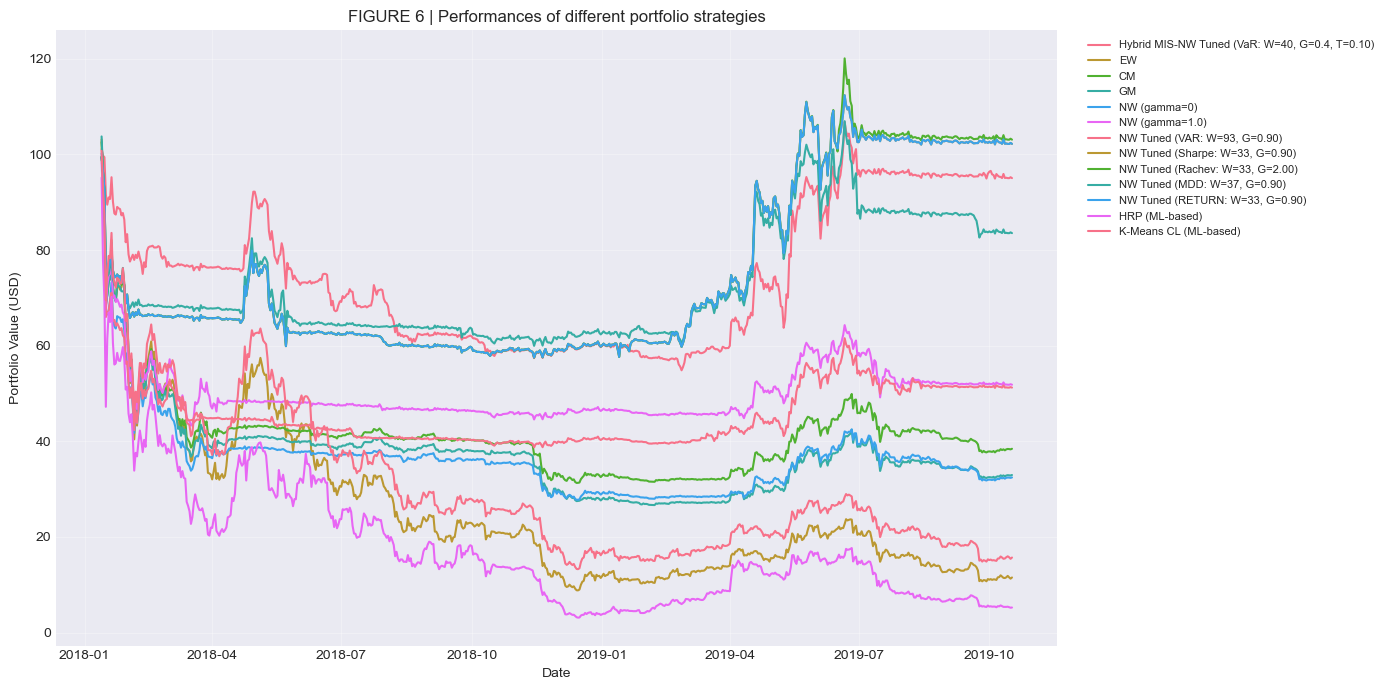

In [15]:
plt.figure(figsize=(14, 7))
for name, res in results.items():
    plt.plot(res['results_df']['date'],
             res['cumulative_returns'] * 100,
             label=name)
plt.title('FIGURE 6 | Performances of different portfolio strategies')
plt.xlabel('Date')
plt.ylabel('Portfolio Value (USD)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
period_ranges = [
    ('Jan-2018', '2017-10-01', '2018-01-31'),
    ('May-2018', '2018-02-01', '2018-05-31'),
    ('Sep-2018', '2018-06-01', '2018-09-30'),
    ('Jan-2019', '2018-10-01', '2019-01-31'),
    ('May-2019', '2019-02-01', '2019-05-31'),
    ('Sep-2019', '2019-06-01', '2019-09-30'),
]

table3_rows = []
for strat in strategies:
    strat_name = strat.name
    if strat_name not in results: continue
    res = results[strat_name]
    df_res = res['results_df'].set_index('date')
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_w = np.mean([p['window'] for p in strat.param_history])
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w, avg_g = strat.window_size, strat.gamma
    else:
        avg_w = getattr(strat, 'window_size', '-')
        avg_g = getattr(strat, 'gamma', '-')
    row    = {'Strategy': strat_name}
    row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w, avg_g = strat.window_size, strat.gamma
    else:
        avg_g = getattr(strat, 'gamma', '-')
    
    row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w, avg_g = strat.window_size, strat.gamma
    else:
        avg_g = getattr(strat, 'gamma', '-')
    row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    for period_label, start, end in period_ranges:
        segment = df_res.loc[start:end, 'return'].values
        if len(segment) > 0:
            v = abs(calculate_var(segment, 0.95)) * 100
        else:
            v = np.nan
        row[period_label] = round(v, 4)
    table3_rows.append(row)

table3 = pd.DataFrame(table3_rows).set_index('Strategy')
print("TABLE 3 | VaR 95% (4-month window, scaled x100)")
display(table3)

TABLE 3 | VaR 95% (4-month window, scaled x100)


,W,G,Jan-2018,May-2018,Sep-2018,Jan-2019,May-2019,Sep-2019
Strategy,,,,,,,,
"Hybrid MIS-NW Tuned (VaR: W=40, G=0.4, T=0.10)",40.0,0.40,5.7251,2.9366,2.7473,1.4058,2.4376,2.0387
EW,120.0,-,13.7904,9.5511,6.5477,9.4876,3.6840,8.2085
CM,120.0,-,12.8261,5.8008,0.9993,1.7255,1.7011,3.8309
GM,120.0,-,13.4648,5.9287,1.1856,2.4277,1.8379,4.2622
NW (gamma=0),120.0,0.00,12.4709,5.6166,1.1500,1.8397,1.5141,4.0012
NW (gamma=1.0),120.0,1.00,10.3486,5.6183,0.7120,0.9561,1.2827,3.0550
"NW Tuned (VAR: W=93, G=0.90)",93.0,0.90,10.6356,4.5306,0.8128,0.9561,1.5065,3.2420
"NW Tuned (Sharpe: W=33, G=0.90)",33.0,0.90,6.5951,2.8816,0.7667,1.1674,2.4558,1.9111
"NW Tuned (Rachev: W=33, G=2.00)",33.0,2.00,6.5951,2.8816,0.7667,1.1674,2.4558,2.7153


In [17]:
table4_rows = []
for strat in strategies:
    strat_name = strat.name
    if strat_name not in results: continue
    res = results[strat_name]
    df_res = res['results_df'].set_index('date')
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_w = np.mean([p['window'] for p in strat.param_history])
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w, avg_g = strat.window_size, strat.gamma
    else:
        avg_w = getattr(strat, 'window_size', '-')
        avg_g = getattr(strat, 'gamma', '-')
    row    = {'Strategy': strat_name}
    row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w, avg_g = strat.window_size, strat.gamma
    else:
        avg_g = getattr(strat, 'gamma', '-')
    
    row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w, avg_g = strat.window_size, strat.gamma
    else:
        avg_g = getattr(strat, 'gamma', '-')
    row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    for period_label, start, end in period_ranges:
        segment = df_res.loc[start:end, 'return'].values
        if len(segment) > 1 and np.std(segment) > 1e-6:
            sr = np.mean(segment) / np.std(segment)
        else:
            sr = np.nan
        row[period_label] = round(sr, 4)
    table4_rows.append(row)

table4 = pd.DataFrame(table4_rows).set_index('Strategy')
print("TABLE 4 | Sharpe Ratio (4-month window)")
display(table4)

TABLE 4 | Sharpe Ratio (4-month window)


,W,G,Jan-2018,May-2018,Sep-2018,Jan-2019,May-2019,Sep-2019
Strategy,,,,,,,,
"Hybrid MIS-NW Tuned (VaR: W=40, G=0.4, T=0.10)",40.0,0.40,-0.3123,-0.0456,-0.1123,-0.0790,0.1654,0.0275
EW,120.0,-,-0.2532,-0.0425,-0.0986,-0.1270,0.2016,-0.1298
CM,120.0,-,-0.2508,-0.0984,-0.0577,-0.1500,0.1904,-0.0598
GM,120.0,-,-0.2355,-0.1032,-0.0537,-0.1873,0.1775,-0.0526
NW (gamma=0),120.0,0.00,-0.3442,-0.1053,-0.0523,-0.1514,0.1851,-0.0694
NW (gamma=1.0),120.0,1.00,-0.3849,-0.0450,-0.0632,-0.0152,0.1567,-0.0498
"NW Tuned (VAR: W=93, G=0.90)",93.0,0.90,-0.4164,-0.0697,-0.1262,-0.0152,0.1692,-0.0216
"NW Tuned (Sharpe: W=33, G=0.90)",33.0,0.90,-0.3728,-0.0415,-0.0913,0.0233,0.1999,-0.0079
"NW Tuned (Rachev: W=33, G=2.00)",33.0,2.00,-0.3728,-0.0415,-0.0913,0.0233,0.2000,-0.0015


In [18]:
table5_rows = []
for strat in strategies:
    strat_name = strat.name
    if strat_name not in results: continue
    res = results[strat_name]
    df_res = res['results_df'].set_index('date')
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_w = np.mean([p['window'] for p in strat.param_history])
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w, avg_g = strat.window_size, strat.gamma
    else:
        avg_w = getattr(strat, 'window_size', '-')
        avg_g = getattr(strat, 'gamma', '-')
    row    = {'Strategy': strat_name}
    row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w, avg_g = strat.window_size, strat.gamma
    else:
        avg_g = getattr(strat, 'gamma', '-')
    
    row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w, avg_g = strat.window_size, strat.gamma
    else:
        avg_g = getattr(strat, 'gamma', '-')
    row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    for period_label, start, end in period_ranges:
        segment = df_res.loc[start:end, 'return'].values
        if len(segment) > 5:
            rr = calculate_rachev_ratio(segment, alpha=0.10)
        else:
            rr = np.nan
        row[period_label] = round(rr, 4)
    table5_rows.append(row)

table5 = pd.DataFrame(table5_rows).set_index('Strategy')
print("TABLE 5 | Rachev Ratio (alpha=10%, 4-month window)")
display(table5)

TABLE 5 | Rachev Ratio (alpha=10%, 4-month window)


,W,G,Jan-2018,May-2018,Sep-2018,Jan-2019,May-2019,Sep-2019
Strategy,,,,,,,,
"Hybrid MIS-NW Tuned (VaR: W=40, G=0.4, T=0.10)",40.0,0.40,0.5290,1.0351,0.6689,0.8721,2.1800,1.0072
EW,120.0,-,0.3926,0.8889,0.8062,0.7200,1.7430,0.5381
CM,120.0,-,0.3969,0.7612,0.7865,0.6506,2.0115,0.7510
GM,120.0,-,0.4126,0.7515,0.7760,0.5600,1.6893,0.7353
NW (gamma=0),120.0,0.00,0.2494,0.7591,0.7824,0.6389,2.1048,0.7820
NW (gamma=1.0),120.0,1.00,0.3488,1.0222,0.8170,1.0171,2.1687,0.8614
"NW Tuned (VAR: W=93, G=0.90)",93.0,0.90,0.1565,0.8720,0.6249,1.0171,2.2650,0.9376
"NW Tuned (Sharpe: W=33, G=0.90)",33.0,0.90,0.1967,0.9248,0.7264,1.1274,2.0842,0.9210
"NW Tuned (Rachev: W=33, G=2.00)",33.0,2.00,0.1967,0.9248,0.7264,1.1274,2.0867,0.9487


In [19]:
fase_pasar = {
    'Bearish':  ('2018-01-01', '2019-03-31'),
    'Recovery': ('2019-04-01', '2019-06-30'),
    'Stable':   ('2019-07-01', '2019-10-17')
}

sharpe_rows = []
rachev_rows = []
for strat in strategies:
    strat_name = strat.name
    if strat_name not in results: continue
    res = results[strat_name]
    df_res = res['results_df'].set_index('date')
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_w = np.mean([p['window'] for p in strat.param_history])
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w, avg_g = strat.window_size, strat.gamma
    else:
        avg_w = getattr(strat, 'window_size', '-')
        avg_g = getattr(strat, 'gamma', '-')
    sr_row = {'Strategy': strat_name}
    sr_row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    sr_row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w, avg_g = strat.window_size, strat.gamma
    else:
        avg_g = getattr(strat, 'gamma', '-')
    
    sr_row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    sr_row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    rr_row = {'Strategy': strat_name}
    rr_row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    rr_row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    rr_row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    rr_row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    for fase, (start, end) in fase_pasar.items():
        segment = df_res.loc[start:end, 'return'].values
        if len(segment) > 1 and np.std(segment) > 1e-6:
            sr = np.mean(segment) / np.std(segment)
        else:
            sr = np.nan
        sr_row[fase] = round(sr, 4)
        if len(segment) > 5:
            rr = calculate_rachev_ratio(segment, alpha=0.10)
        else:
            rr = np.nan
        rr_row[fase] = round(rr, 4)
    sharpe_rows.append(sr_row)
    rachev_rows.append(rr_row)

table6_sharpe = pd.DataFrame(sharpe_rows).set_index('Strategy')
table6_rachev = pd.DataFrame(rachev_rows).set_index('Strategy')

print("TABLE 6 | Market Phase Performance")
print("\nPanel A: Sharpe Ratio")
display(table6_sharpe)
print("\nPanel B: Rachev Ratio (alpha=10%)")
display(table6_rachev)

TABLE 6 | Market Phase Performance

Panel A: Sharpe Ratio


,W,G,Bearish,Recovery,Stable
Strategy,,,,,
"Hybrid MIS-NW Tuned (VaR: W=40, G=0.4, T=0.10)",40.0,0.40,-0.0764,0.1680,-0.0112
EW,120.0,-,-0.0726,0.1286,-0.1301
CM,120.0,-,-0.0923,0.1844,-0.1022
GM,120.0,-,-0.0991,0.1732,-0.0950
NW (gamma=0),120.0,0.00,-0.1072,0.1763,-0.1095
NW (gamma=1.0),120.0,1.00,-0.0685,0.1359,-0.0628
"NW Tuned (VAR: W=93, G=0.90)",93.0,0.90,-0.0837,0.1318,-0.0402
"NW Tuned (Sharpe: W=33, G=0.90)",33.0,0.90,-0.0399,0.1413,-0.0048
"NW Tuned (Rachev: W=33, G=2.00)",33.0,2.00,-0.0399,0.1392,-0.0048



Panel B: Rachev Ratio (alpha=10%)


,W,G,Bearish,Recovery,Stable
Strategy,,,,,
"Hybrid MIS-NW Tuned (VaR: W=40, G=0.4, T=0.10)",40.0,0.40,0.8209,1.6773,1.0864
EW,120.0,-,0.7933,1.2168,0.5712
CM,120.0,-,0.6463,1.2463,0.7523
GM,120.0,-,0.6275,1.1627,0.7477
NW (gamma=0),120.0,0.00,0.5982,1.2883,0.7615
NW (gamma=1.0),120.0,1.00,0.7244,1.4069,0.8656
"NW Tuned (VAR: W=93, G=0.90)",93.0,0.90,0.6220,1.3659,1.0037
"NW Tuned (Sharpe: W=33, G=0.90)",33.0,0.90,0.8384,1.4926,1.1048
"NW Tuned (Rachev: W=33, G=2.00)",33.0,2.00,0.8384,1.4174,1.1048


In [20]:
print("Grid Search Tuned Parameters:")
for metric, params in tuned_params.items():
    print(f"  {metric}: W={params['W']}, G={params['G']:.1f}")

Grid Search Tuned Parameters:
  VAR: W=93, G=0.9
  SHARPE: W=33, G=0.9
  RACHEV: W=33, G=2.0
  MDD: W=37, G=0.9
  RETURN: W=33, G=0.9


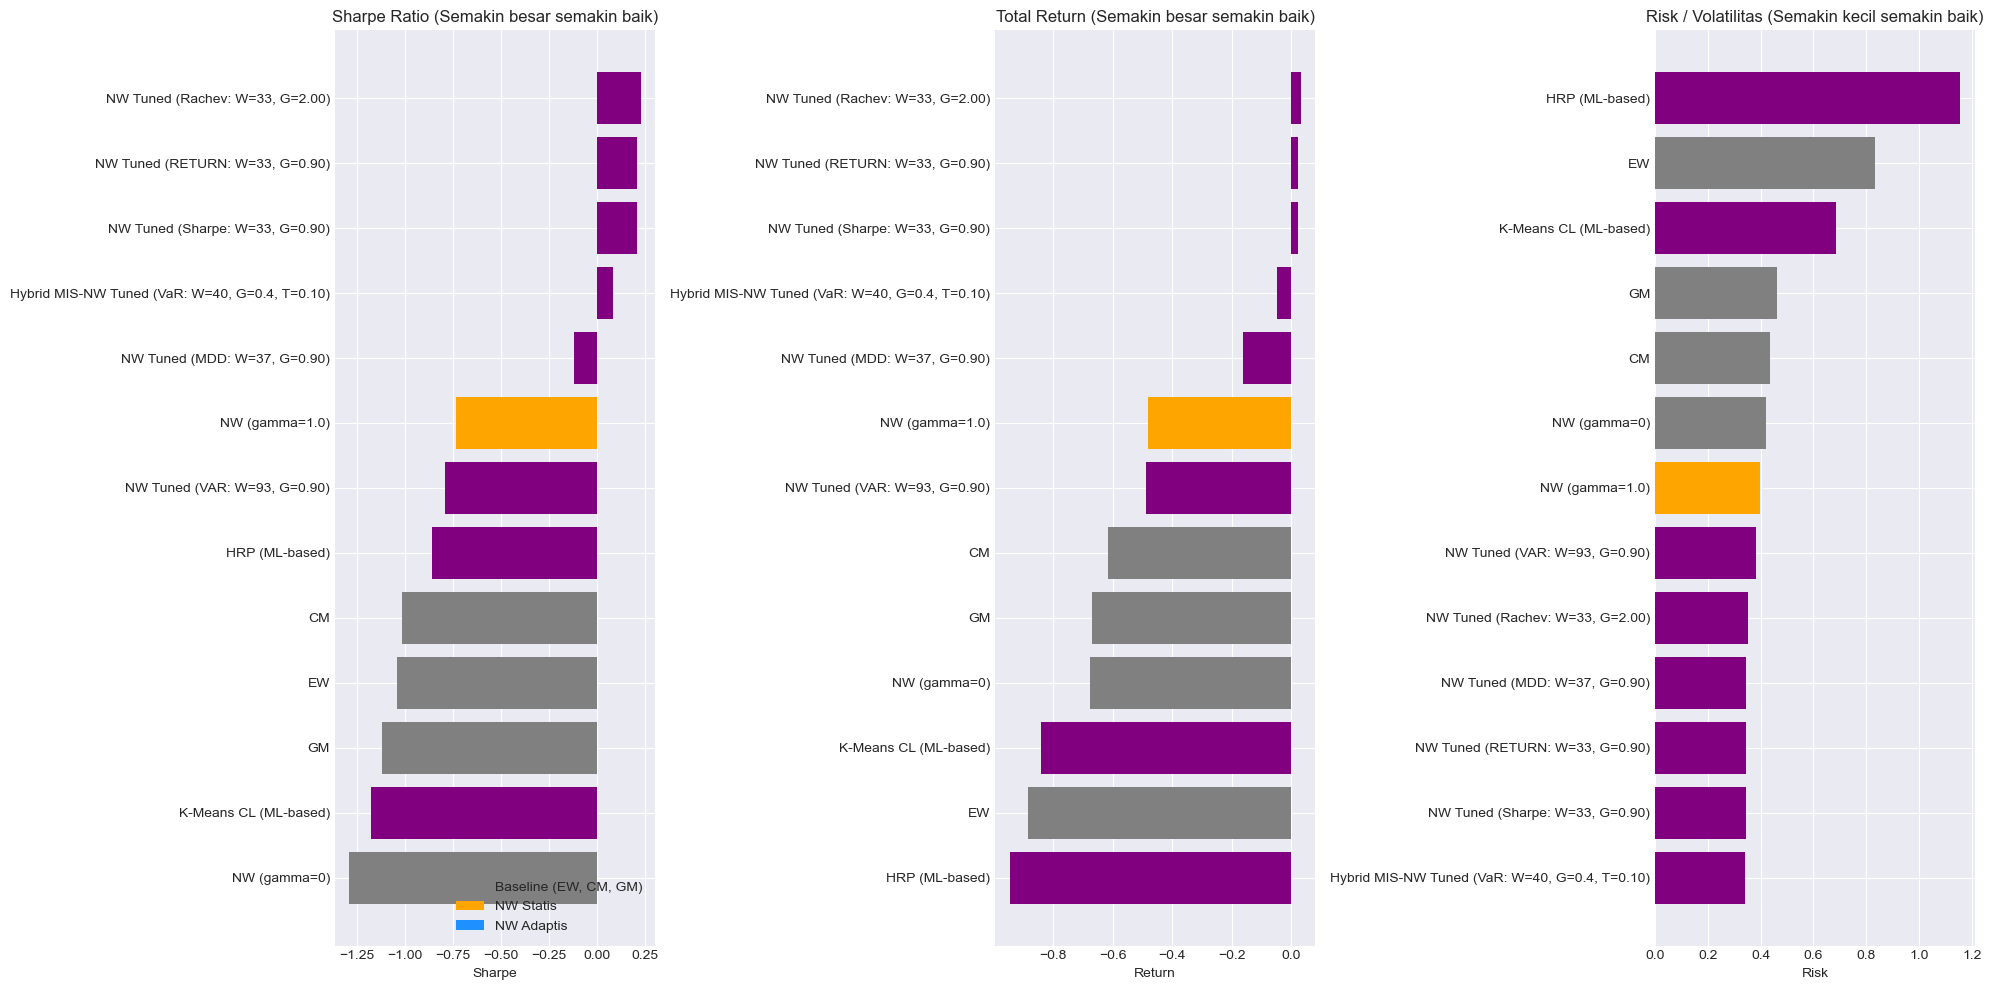

In [21]:
import numpy as np

data_rows = []
for strat_name, res in results.items():
    df_res = res['results_df']
    returns = df_res['return'].dropna().values
    
    if len(returns) > 0:
        tot_ret = np.prod(1 + returns) - 1 # or np.sum(returns) if log returns
        risk = np.std(returns) * np.sqrt(365) # annualized volatility
        sharpe = (np.mean(returns) / np.std(returns)) * np.sqrt(365) if np.std(returns) > 1e-6 else 0
    else:
        tot_ret, risk, sharpe = 0, 0, 0
        
    data_rows.append({'Strategy': strat_name, 'Return': tot_ret, 'Risk': risk, 'Sharpe': sharpe})

comparison = pd.DataFrame(data_rows).set_index('Strategy')

def get_color(strategy_name):
    if strategy_name in ['EW', 'CM', 'CM 30', 'GM'] or 'Static' not in strategy_name and 'gamma=0' in strategy_name:
        return 'gray'
    elif 'NW Static' in strategy_name or '(gamma' in strategy_name:
        return 'orange' # Static NW
    elif 'Adaptis' in strategy_name or 'GS' in strategy_name:
        return 'dodgerblue' # Adaptive NW
    else:
        return 'purple'

colors = [get_color(idx) for idx in comparison.index]

fig, axes = plt.subplots(1, 3, figsize=(20, 10))

df_sharpe = comparison['Sharpe'].sort_values(ascending=True)
c_sharpe = [get_color(idx) for idx in df_sharpe.index]
axes[0].barh(df_sharpe.index, df_sharpe.values, color=c_sharpe)
axes[0].set_title('Sharpe Ratio (Semakin besar semakin baik)')
axes[0].set_xlabel('Sharpe')

df_return = comparison['Return'].sort_values(ascending=True)
c_return = [get_color(idx) for idx in df_return.index]
axes[1].barh(df_return.index, df_return.values, color=c_return)
axes[1].set_title('Total Return (Semakin besar semakin baik)')
axes[1].set_xlabel('Return')

df_risk = comparison['Risk'].sort_values(ascending=True)
c_risk = [get_color(idx) for idx in df_risk.index]
axes[2].barh(df_risk.index, df_risk.values, color=c_risk)
axes[2].set_title('Risk / Volatilitas (Semakin kecil semakin baik)')
axes[2].set_xlabel('Risk')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='gray', label='Baseline (EW, CM, GM)'),
                   Patch(facecolor='orange', label='NW Statis'),
                   Patch(facecolor='dodgerblue', label='NW Adaptis')]
axes[0].legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

fig.savefig('horizontal_bar_comparison.png', dpi=300, bbox_inches='tight')
